在基于dqn的基础上设计madqn将各个agent协同完成任务时，发现原作的一个问题。
先看原作的算法：

<img src="figs/image.png" style="width:50%;">

这个算法有一个问题，就是所有的agent采用的都是各自不同的神经网络，也就是说madqn只是将dqn的数量增加，没有互相之间的协同，只是各自完成各自的任务，只要不发生碰撞就行。
但是这样子真的是madqn吗？为什么不能把所有agent的state进行拼接，组合为states vector再训练呢？
调试一下组合states再embedding的方法。

In [1]:
import sys
import os

sys.argv = ['']
sys.path.append("..")

from env.env import Env
from rl_algorithms.agent import Agent
from rl_algorithms.dqn import Qnet, ReplayBuffer

from tqdm import tqdm
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import torch
from typing import List, Tuple, Any, Optional
from collections import deque
import random
import numpy as np

In [2]:
def state_to_idx_tensor(state, y_dim, device):
    """
    将状态转换为 state idx 张量
    :param state: 单个状态 (x, y) 或批量状态数组 (batch, 2)
    :return: state idx tensor，单个状态返回形状 (1,)，批量状态返回形状 (batch,)
    """
    if isinstance(state, (tuple, list, np.ndarray)) and len(state) == 2 and isinstance(state[0], (int, np.integer)):
        # 单个状态 (x, y)
        state_idx = int(state[0]) * y_dim + int(state[1])
        state_idx_tensor = torch.tensor(
            [state_idx], dtype=torch.long, device=device)
    else:
        # 批量状态 (batch, 2)
        state = np.array(state, dtype=np.int64)
        state_indices = state[:, 0] * y_dim + state[:, 1]
        state_idx_tensor = torch.tensor(
            state_indices, dtype=torch.long, device=device)
    return state_idx_tensor

In [3]:
def idx_tensor_to_state(idx_tensor, y_dim):
    """
    将 state idx 张量转换为状态
    :param idx_tensor: state idx tensor，单个状态返回形状 (1,) 或标量，批量状态返回形状 (batch,)
    :param y_dim: 环境 y 维度
    :return: 状态数组，单个状态返回形状 (2,)，批量状态返回形状 (batch, 2)
    """
    # 转换为 numpy 数组以便处理
    if isinstance(idx_tensor, torch.Tensor):
        idx_array = idx_tensor.cpu().numpy()
    elif isinstance(idx_tensor, (int, np.integer)):
        # 单个标量
        idx_array = np.array([idx_tensor])
    else:
        idx_array = np.array(idx_tensor)

    # 确保是一维数组
    if idx_array.ndim == 0:
        idx_array = idx_array.reshape(1)

    # 计算状态坐标
    state_x = idx_array // y_dim
    state_y = idx_array % y_dim

    # 判断是单个状态还是批量状态
    if len(idx_array) == 1:
        # 单个状态 (x, y)
        state = np.array([int(state_x[0]), int(state_y[0])], dtype=np.int64)
    else:
        # 批量状态 (batch, 2)
        state = np.stack([state_x, state_y], axis=1).astype(np.int64)

    return state

In [4]:
def calculate_distance(state_idx, targets_idx, y_dim=10, x_dim=10, device='cpu'):
    """
    计算状态到目标的距离信息
    支持两种模式：
    1. 批量模式：state_idx 和 targets_idx 形状相同 (B,)，每个样本的 state 对应一个 target
    2. 多目标模式：state_idx 是单个值，targets_idx 是多个值 (num_targets,)，计算单个 state 到多个 targets 的距离
    
    :param state_idx: 状态索引，torch.Tensor 形状 (B,) 或 (1,) 或标量
    :param targets_idx: 目标索引，torch.Tensor 形状 (B,) 或 (num_targets,)
    :param y_dim: 环境 y 维度
    :param x_dim: 环境 x 维度
    :param device: 设备
    :return: 字典，包含 state_idx, targets_idx 和所有距离特征
    """
    # 确保 state_idx 和 targets_idx 是 torch.Tensor
    if not isinstance(state_idx, torch.Tensor):
        state_idx = torch.tensor([state_idx] if isinstance(
            state_idx, (int, np.integer)) else state_idx, device=device)
    if not isinstance(targets_idx, torch.Tensor):
        targets_idx = torch.tensor(targets_idx, device=device)

    # 确保在正确的设备上
    state_idx = state_idx.to(device)
    targets_idx = targets_idx.to(device)

    # 转换为状态坐标
    state = idx_tensor_to_state(state_idx, y_dim)  # 单个状态: (2,), 批量状态: (B, 2)
    # 单个目标: (2,), 批量目标: (B, 2) 或 (num_targets, 2)
    targets = idx_tensor_to_state(targets_idx, y_dim)

    # 转换为 torch tensor
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
    targets_tensor = torch.tensor(targets, dtype=torch.float32, device=device)

    # 判断处理模式
    if state_tensor.ndim == 1 and state_tensor.shape[0] == 2:
        # 单个 state 模式
        if targets_tensor.ndim == 1 and targets_tensor.shape[0] == 2:
            # 单个 state 到单个 target
            state_expanded = state_tensor.unsqueeze(0)  # (1, 2)
            targets_expanded = targets_tensor.unsqueeze(0)  # (1, 2)
            dx = (targets_expanded[:, 0] - state_expanded[0, 0])  # (1,)
            dy = (targets_expanded[:, 1] - state_expanded[0, 1])  # (1,)
        else:
            # 单个 state 到多个 targets
            state_expanded = state_tensor.unsqueeze(0)  # (1, 2)
            # (num_targets,)
            dx = (targets_tensor[:, 0] - state_expanded[0, 0])
            # (num_targets,)
            dy = (targets_tensor[:, 1] - state_expanded[0, 1])
    else:
        # 批量模式：state 和 target 数量相同
        dx = (targets_tensor[:, 0] - state_tensor[:, 0])  # (B,)
        dy = (targets_tensor[:, 1] - state_tensor[:, 1])  # (B,)

    # 归一化
    dx_n = dx / x_dim
    dy_n = dy / y_dim

    # 计算距离特征
    abs_dx = torch.abs(dx_n)
    abs_dy = torch.abs(dy_n)
    l1 = abs_dx + abs_dy
    l2 = torch.sqrt(dx_n ** 2 + dy_n ** 2 + 1e-8)
    sign_dx = torch.sign(dx_n)
    sign_dy = torch.sign(dy_n)

    # 返回包含 state_idx 和所有 target 距离信息的字典
    return {
        'state_idx': state_idx,
        'targets_idx': targets_idx,
        'state_coord': state_tensor,
        'targets_coord': targets_tensor,
        'dx_n': dx_n,
        'dy_n': dy_n,
        'abs_dx': abs_dx,
        'abs_dy': abs_dy,
        'l1': l1,
        'l2': l2,
        'sign_dx': sign_dx,
        'sign_dy': sign_dy,
    }

In [5]:
class ReplayBuffer:
    """
    ReplayBuffer，用于存储经验
    """

    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

In [6]:
class Qnet(nn.Module):
    """
    Q(s, a | target)

    target 通过 embedding 输入网络
    相对位置信息作为主干
    """

    def __init__(
        self,
        state_num: int,
        action_dim: int,
        x_dim: int,
        y_dim: int,
        embedding_dim: int = 32,
        hidden_dim: int = 128,
    ):
        super().__init__()

        self.x_dim = x_dim
        self.y_dim = y_dim

        # ===== state embedding =====
        self.embedding = nn.Embedding(state_num, embedding_dim)

        self.abs_fc = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
        )

        # ===== target embedding branch =====
        self.target_fc = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
        )

        # ===== relative position branch（主干）=====
        self.rel_fc = nn.Sequential(
            nn.Linear(8, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # ===== fusion head =====
        # 融合 state embedding, target embedding 和 relative position (64 + 64 + 64 = 192)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, state_idx: torch.Tensor, target_idx: torch.Tensor):
        """
        state_idx: (B,)
        target_idx: (B,)
        """

        # ===== absolute state embedding =====
        state_emb = self.embedding(state_idx)
        h_abs = self.abs_fc(state_emb)

        # ===== target embedding =====
        target_emb = self.embedding(target_idx)
        h_target = self.target_fc(target_emb)

        # ===== relative position to target using calculate_distance =====
        # 使用 calculate_distance 计算相对位置特征（批量处理）
        device = state_idx.device
        distance_info = calculate_distance(
            state_idx,
            target_idx,
            y_dim=self.y_dim,
            x_dim=self.x_dim,
            device=device
        )

        # 提取相对位置特征并堆叠 (B, 8)
        rel_feat = torch.stack([
            distance_info['dx_n'],
            distance_info['dy_n'],
            distance_info['abs_dx'],
            distance_info['abs_dy'],
            distance_info['l1'],
            distance_info['l2'],
            distance_info['sign_dx'],
            distance_info['sign_dy'],
        ], dim=1)  # (B, 8)

        h_rel = self.rel_fc(rel_feat)

        # ===== fusion =====
        h = torch.cat([h_abs, h_target, h_rel], dim=1)
        q = self.head(h)

        return q

In [7]:
class MADQN(Agent):
    def __init__(self, 
                 env, lr=0.001, gamma=0.99, 
                 epsilon=1.0, epsilon_min=0.1, epsilon_decay=0.9, 
                 num_episodes=5, episode_length=35000,
                 iteration=5, batch_size=64, mini_batch_size=64,
                 hidden_dim=128, update_freq=10):
        super().__init__(env=env, 
                         lr=lr, gamma=gamma, 
                         epsilon=epsilon, epsilon_min=epsilon_min, 
                         epsilon_decay=epsilon_decay, 
                         num_episodes=num_episodes, episode_length=episode_length)
        
        self.num_agents = env.num_agents
        self.iteration = iteration
        
        # 初始化经验回放缓冲区（每个 agent 一个）
        self.buffer = [ReplayBuffer(episode_length * num_episodes * env.num_agents) 
                       for _ in range(self.num_agents)]
        self.batch_size = batch_size
        self.mini_batch_size = mini_batch_size
        
        self.hidden_dim = hidden_dim
        
        # 初始化Q网络和目标Q网络（每个 agent 一个）
        state_num = env.state_num  # 总状态数
        self.q_nets = [Qnet(state_num=state_num, embedding_dim=64, hidden_dim=hidden_dim, 
                            action_dim=env.num_actions, x_dim=env.x_dim, y_dim=env.y_dim)
                       for _ in range(self.num_agents)]
        self.target_q_nets = [Qnet(state_num=state_num, embedding_dim=64, hidden_dim=hidden_dim, 
                                   action_dim=env.num_actions, x_dim=env.x_dim, y_dim=env.y_dim)
                              for _ in range(self.num_agents)]
        
        # 初始化目标网络参数
        for i in range(self.num_agents):
            self.target_q_nets[i].load_state_dict(self.q_nets[i].state_dict())
            self.target_q_nets[i].eval()
        
        # 初始化优化器和损失函数（每个 agent 一个）
        self.optimizers = [optim.Adam(self.q_nets[i].parameters(), lr=lr)
                          for i in range(self.num_agents)]
        self.loss_fn = nn.MSELoss()
        
        # 初始化设备
        self.device = torch.device("cpu")
        for i in range(self.num_agents):
            self.q_nets[i].to(self.device)
            self.target_q_nets[i].to(self.device)
        
        self.update_freq = update_freq
        
    def take_action(self, states, training=True):
        """
        所有agent一起选择动作，每个agent只向自己的target移动
        :param states: 所有agent的状态列表，长度为num_agents
        :param training: 是否处于训练模式
        :return: 所有agent的动作索引列表，长度为num_agents
        """
        actions = []
        
        # 为每个agent选择动作
        for agent_id in range(self.num_agents):
            # 获取当前agent对应的target
            target = self.env.target_states[agent_id]
            
            # 将当前agent的状态转换为 state_idx
            state = states[agent_id]
            state_idx_tensor = state_to_idx_tensor(state, self.env.y_dim, self.device)  # (1,)
            
            # 将当前agent的target转换为 target_idx_tensor
            target_idx_tensor = state_to_idx_tensor(target, self.env.y_dim, self.device)  # (1,)
            
            with torch.no_grad():
                # 使用对应 agent 的 Q 网络计算 Q 值，形状为 (1, action_dim)
                action_values = self.q_nets[agent_id](state_idx_tensor, target_idx_tensor)
            
            # 获取最优动作
            optimal_action = action_values.argmax(dim=1).item()
            
            if training:
                # 概率分配：最优动作概率最大，其他动作概率相同
                # 最优动作概率：1 - epsilon + epsilon/num_actions
                # 其他动作概率：epsilon/num_actions
                num_actions = self.env.num_actions
                probs = torch.full((num_actions,), self.epsilon / num_actions, device=self.device)
                probs[optimal_action] = 1 - self.epsilon + self.epsilon / num_actions
                
                # 根据概率分布采样动作
                dist = torch.distributions.Categorical(probs=probs)
                action = dist.sample().item()
                actions.append(action)
            else:
                # 测试模式：直接返回最优动作
                actions.append(optimal_action)
        
        return actions

    def update(self, agent_id):
        """
        更新指定 agent 的 Q 网络，每个agent只考虑自己的target
        :param agent_id: 机器人编号
        :return: loss值
        """
        if len(self.buffer[agent_id]) < self.mini_batch_size:
            return None
        
        batch = self.buffer[agent_id].sample(self.mini_batch_size)

        # 统一处理 state 格式：确保所有 state 都是 [x, y] 格式
        def normalize_state(s):
            """将各种格式的state转换为 [x, y] 格式"""
            if isinstance(s, np.ndarray):
                s = s.flatten()
                if len(s) >= 2:
                    return [int(s[0]), int(s[1])]
            elif isinstance(s, (tuple, list)):
                # 处理嵌套情况：如果第一个元素是tuple/list，递归处理
                if len(s) >= 2:
                    first_elem = s[0]
                    if isinstance(first_elem, (tuple, list, np.ndarray)):
                        # 嵌套情况，取第一个元素
                        return normalize_state(first_elem)
                    else:
                        # 正常情况
                        return [int(s[0]), int(s[1])]
            # 如果都不匹配，尝试直接转换
            try:
                s_array = np.array(s).flatten()
                if len(s_array) >= 2:
                    return [int(s_array[0]), int(s_array[1])]
            except:
                pass
            # 最后的fallback
            return [0, 0]
        
        states = []
        for b in batch:
            state = normalize_state(b[0])
            states.append(state)
        states = np.array(states, dtype=np.int64)
        
        actions = np.array([b[1] for b in batch])
        rewards = np.array([b[2] for b in batch], dtype=np.float32)
        
        # 统一处理 next_state 格式
        next_states = []
        for b in batch:
            next_state = normalize_state(b[3])
            next_states.append(next_state)
        next_states = np.array(next_states, dtype=np.int64)
        dones = np.array([b[4] for b in batch], dtype=np.float32)

        state_idx = state_to_idx_tensor(states, self.env.y_dim, self.device)  # (batch_size,)
        next_state_idx = state_to_idx_tensor(
            next_states, self.env.y_dim, self.device)  # (batch_size,)

        action_tensor = torch.tensor(actions, dtype=torch.long, device=self.device)
        reward_tensor = torch.tensor(rewards, device=self.device)

        # 获取当前agent对应的target
        target = self.env.target_states[agent_id]
        target_idx = state_to_idx_tensor(target, self.env.y_dim, self.device)  # (1,)
        # 扩展到batch_size
        target_idx_expanded = target_idx.repeat(len(batch))  # (batch_size,)
        
        # 计算Q值
        q = self.q_nets[agent_id](state_idx, target_idx_expanded)  # (batch_size, action_dim)
        q = q.gather(1, action_tensor.unsqueeze(1)).squeeze(1)  # (batch_size,)
        
        # 计算TD target
        with torch.no_grad():
            next_q = self.target_q_nets[agent_id](next_state_idx, target_idx_expanded)  # (batch_size, action_dim)
            max_next_q = next_q.max(dim=1)[0]  # (batch_size,)
            td_target = reward_tensor + self.gamma * max_next_q * (1 - torch.tensor(dones, device=self.device))  # (batch_size,)
        
        # 计算loss
        loss = self.loss_fn(q, td_target)

        self.optimizers[agent_id].zero_grad()
        loss.backward()
        self.optimizers[agent_id].step()

        return loss.item()
    
    def update_target_qnet(self, agent_id):
        """同步指定 agent 的目标Q网络参数"""
        self.target_q_nets[agent_id].load_state_dict(self.q_nets[agent_id].state_dict())

    def save(self, path: str):
        """保存所有 agent 的模型"""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        checkpoint = {
            "epsilon": self.epsilon,
        }
        # 保存每个 agent 的网络和优化器
        for i in range(self.num_agents):
            checkpoint[f"qnet_{i}"] = self.q_nets[i].state_dict()
            checkpoint[f"target_qnet_{i}"] = self.target_q_nets[i].state_dict()
            checkpoint[f"optimizer_{i}"] = self.optimizers[i].state_dict()
        torch.save(checkpoint, path)
        print(f"模型已保存到: {path}")
    
    def load(self, path: str):
        """加载所有 agent 的模型"""
        if not os.path.isfile(path):
            raise FileNotFoundError(f"未找到模型文件: {path}")
        checkpoint = torch.load(path, map_location=self.device)
        # 加载每个 agent 的网络和优化器
        for i in range(self.num_agents):
            self.q_nets[i].load_state_dict(checkpoint[f"qnet_{i}"])
            self.target_q_nets[i].load_state_dict(
                checkpoint.get(f"target_qnet_{i}", checkpoint[f"qnet_{i}"]))
            self.optimizers[i].load_state_dict(checkpoint[f"optimizer_{i}"])
        self.epsilon = checkpoint.get("epsilon", self.epsilon)
        

In [8]:
def train_madqn(env, madqn):
    print(f"Begin to train MADQN, iteration: {madqn.iteration}")
    epsilon = madqn.epsilon
    return_list = []
    # 记录每个agent的return列表
    agent_return_lists = [[] for _ in range(madqn.num_agents)]
    
    for i in range(madqn.iteration):
        madqn.epsilon = epsilon
        # 使用tqdm创建进度条
        pbar = tqdm(range(1, madqn.num_episodes + 1),
                    desc=f"Iteration({i+1}) progress", unit="episode")
        for ep in pbar:
            states, _ = env.reset()
            # 处理单个 agent 的情况（向后兼容）
            if env.num_agents == 1:
                states = [states]
            
            # 跟踪每个agent的return（到达目的地后不再增加）
            agent_returns = [0.0] * madqn.num_agents
            # 跟踪每个agent是否已到达目的地
            agent_arrived = [False] * madqn.num_agents
            
            ep_return = 0
            for t in range(madqn.episode_length):
                # 所有 agent 一起选择动作（每个agent只向自己的target移动）
                action_indices = madqn.take_action(states, training=True)
                actions = [env.action_space[action_idx] for action_idx in action_indices]
                
                # 执行动作
                step_result = env.step(actions)
                next_states, rewards, dones, _ = step_result
                
                # 处理单个 agent 的情况（向后兼容）
                if env.num_agents == 1:
                    next_states = [next_states]
                    rewards = [rewards]
                    dones = [dones]
                
                # 更新每个agent的return
                for agent_id in range(madqn.num_agents):
                    # 如果agent刚到达目的地（之前未到达，现在done了）
                    if not agent_arrived[agent_id] and dones[agent_id]:
                        agent_arrived[agent_id] = True
                        # 到达目的地时的reward计入return
                        agent_returns[agent_id] += rewards[agent_id]
                    elif not agent_arrived[agent_id]:
                        # 如果还未到达目的地，继续累加reward
                        agent_returns[agent_id] += rewards[agent_id]
                    # 如果已经到达目的地，不再累加reward（即使还在原地）
                
                ep_return = sum(agent_returns)  # 总回报是所有 agent 的回报之和
                
                # 存储经验到对应的 buffer
                for agent_id in range(madqn.num_agents):
                    madqn.buffer[agent_id].add(
                        states[agent_id], 
                        action_indices[agent_id], 
                        rewards[agent_id], 
                        next_states[agent_id], 
                        dones[agent_id]
                    )
                    
                    # 更新网络（每个agent只考虑自己的target）
                    if len(madqn.buffer[agent_id]) >= madqn.mini_batch_size:
                        madqn.update(agent_id)
                
                states = next_states
                
                # 更新目标网络
                if t % madqn.update_freq == 0:
                    for agent_id in range(madqn.num_agents):
                        madqn.update_target_qnet(agent_id)
                
                # 如果所有 agent 都完成，则结束
                if all(dones):
                    break
            
            return_list.append(ep_return)
            # 记录每个agent的return
            for agent_id in range(madqn.num_agents):
                agent_return_lists[agent_id].append(agent_returns[agent_id])
            
            # epsilon **按 episode 衰减**
            madqn.epsilon = max(madqn.epsilon_min, madqn.epsilon * madqn.epsilon_decay)
            
            # 构建进度条显示信息：显示每个agent的return
            return_str = ', '.join([f'A{i+1}:{r:.2f}' for i, r in enumerate(agent_returns)])
            pbar.set_postfix({
                'Episode': ep,
                'Total Return': f'{ep_return:.2f}',
                'Agent Returns': return_str,
                'Epsilon': f'{madqn.epsilon:.3f}'
            })
    return madqn, return_list, agent_return_lists

In [9]:
env = Env()
madqn = MADQN(
    env,
    lr=1e-3,
    gamma=0.99,
    iteration=5,
    epsilon=0.8,
    epsilon_decay=0.95,   # 按 episode
    epsilon_min=0.1,
    num_episodes=50,
    episode_length=35000,
    mini_batch_size=64,
    update_freq=10
)

madqn, return_list, agent_return_lists = train_madqn(env, madqn)
madqn.save("../models/madqn_model_test.pth")

Begin to train MADQN, iteration: 5


Iteration(5) progress: 100%|██████████| 50/50 [00:38<00:00,  1.30episode/s, Episode=50, Total Return=-166.00, Agent Returns=A1:-75.00, A2:-91.00, Epsilon=0.100]  

模型已保存到: ../models/madqn_model_test.pth


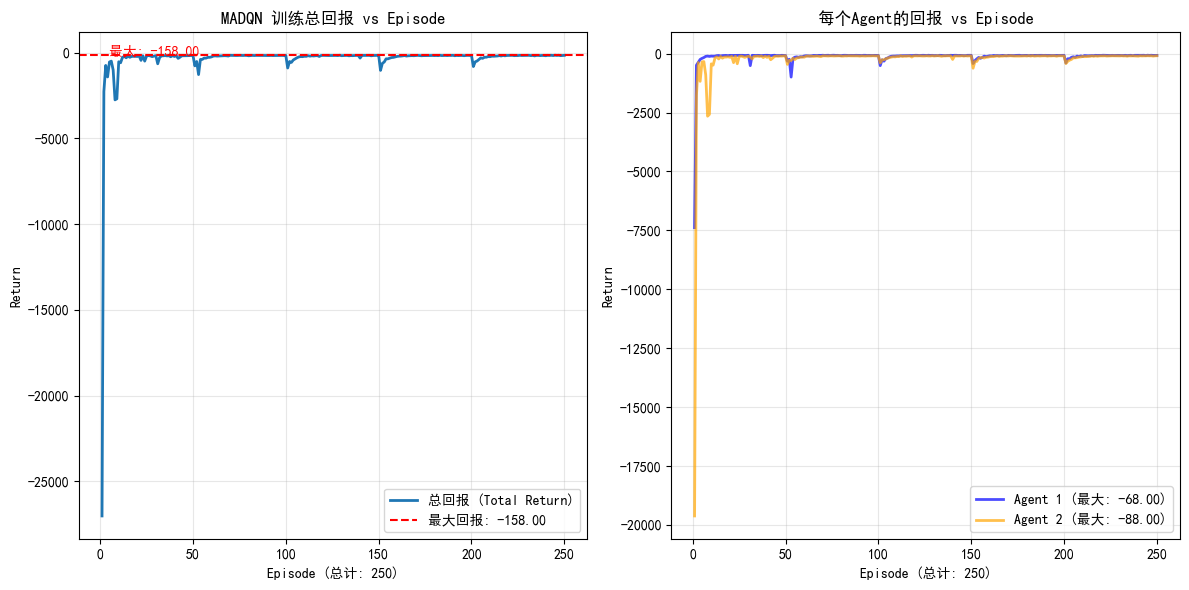

In [10]:
# plot
import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 绘制总return和每个agent的return
total_episodes = madqn.iteration * madqn.num_episodes
max_return = max(return_list)

plt.figure(figsize=(12, 6))

# 绘制总return
plt.subplot(1, 2, 1)
plt.plot(range(1, len(return_list)+1), return_list, label="总回报 (Total Return)", linewidth=2)
plt.axhline(y=max_return, color='r', linestyle='--', label=f"最大回报: {max_return:.2f}")
plt.xlabel(f'Episode (总计: {len(return_list)})')
plt.ylabel('Return')
plt.title('MADQN 训练总回报 vs Episode')
plt.grid(True, alpha=0.3)
plt.legend()
plt.text(len(return_list) * 0.02, max_return * 1.02, f'最大: {max_return:.2f}', 
         fontsize=10, color='r', fontweight='bold')

# 绘制每个agent的return
plt.subplot(1, 2, 2)
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
for agent_id in range(madqn.num_agents):
    agent_returns = agent_return_lists[agent_id]
    max_agent_return = max(agent_returns) if agent_returns else 0
    plt.plot(range(1, len(agent_returns)+1), agent_returns, 
             label=f'Agent {agent_id+1} (最大: {max_agent_return:.2f})', 
             color=colors[agent_id % len(colors)], linewidth=2, alpha=0.7)

plt.xlabel(f'Episode (总计: {len(return_list)})')
plt.ylabel('Return')
plt.title('每个Agent的回报 vs Episode')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

plt.tight_layout()
plt.show()